In [2]:
import tensorflow as tf
from pathlib import Path

base_dir = Path.cwd()

train_dir = Path(base_dir) / "dataset" / "Train_preprocessed"
test_dir = Path(base_dir) / "dataset" / "Test_preprocessed"
h, w = 224, 224

train = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", color_mode="grayscale", seed=42, image_size=(h, w), batch_size=32, label_mode="int"
)
val = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", color_mode="grayscale", seed=42, image_size=(h, w), batch_size=32, label_mode="int"
)
test = tf.keras.utils.image_dataset_from_directory(
    test_dir, color_mode="grayscale", seed=42, image_size=(h, w), batch_size=32, label_mode="int"
)

AUTOTUNE = tf.data.AUTOTUNE
train = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val = val.cache().prefetch(buffer_size=AUTOTUNE)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [ ]:
tf.random.set_seed(42)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 1)),
    tf.keras.layers.Flatten(input_shape=[224, 224]),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])
model.summary()

c:\Users\Adisa Teslim\OneDrive\Documents\Programming Journey\Machine Learning\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Adisa Teslim\OneDrive\Documents\Programming Journey\Machine Learning\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,855,364 (98.63 MB)

 Trainable params: 25,855,364 (98.63 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpoints.weights.h5", save_weights_only=True, save_best_only=True)

history = model.fit(train, validation_data=val, epochs=20, callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/20


c:\Users\Adisa Teslim\OneDrive\Documents\Programming Journey\Machine Learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 321ms/step - accuracy: 0.3982 - loss: 2.4178 - val_accuracy: 0.6438 - val_loss: 0.9274
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 207ms/step - accuracy: 0.5560 - loss: 1.0233 - val_accuracy: 0.6848 - val_loss: 0.8778
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 248ms/step - accuracy: 0.5857 - loss: 0.9436 - val_accuracy: 0.6821 - val_loss: 0.7328
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.5951 - loss: 0.9200 - val_accuracy: 0.6607 - val_loss: 0.7988
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms/step - accuracy: 0.6000 - loss: 0.9119 - val_accuracy: 0.6857 - val_loss: 0.8514
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 212ms/step - accuracy: 0.6152 - loss: 0.8799 - val_accuracy: 0.7152 - val_loss: 0.6907
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.6011 - loss: 0.8950 - val_accuracy: 0.6902 - val_loss: 0.8137
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.5987 - loss: 0.9094 - val

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Brain Tumor CLF Confusion Matrix')
    plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Classification Report
{'glioma': {'precision': 0.2589703588143526, 'recall': 0.415, 'f1-score': 0.31892411143131605, 'support': 400.0}, 'meningioma': {'precision': 0.22580645161290322, 'recall': 0.0175, 'f1-score': 0.03248259860788863, 'support': 400.0}, 'no_tumor': {'precision': 0.2816326530612245, 'recall': 0.345, 'f1-score': 0.3101123595505618, 'support': 400.0}, 'pituitary': {'precision': 0.2602739726027397, 'recall': 0.285, 'f1-score': 0.2720763723150358, 'support': 400.0}, 'accuracy': 0.265625, 'macro avg': {'precision': 0.256670859022805, 'recall': 0.265625, 'f1-score': 0.23339886047620056, 'support': 1600.0}, 'weighted avg': {'precision': 0.25667085902280495, 'recall': 0.265625, 'f1-score': 0.2333988604762006, 'support': 1600.0}}


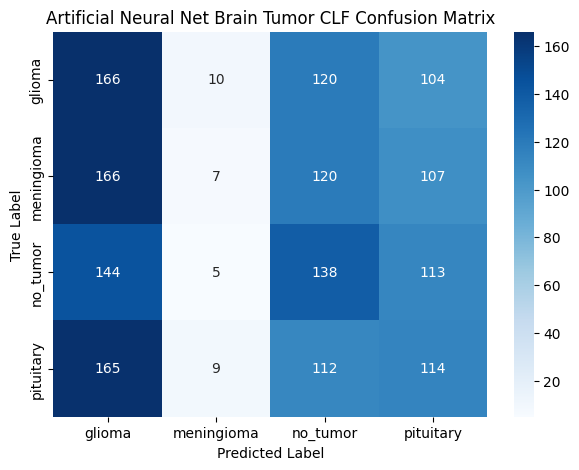

Macro-Averaged ROC-AUC: 0.5132


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

y_true = np.concatenate([y for x, y in test], axis=0)
y_prob = model.predict(test)
y_pred = np.argmax(y_prob, axis=1)

target_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
report_dict = classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_true, y_pred, "Artificial Neural Net")

auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "artificial_neural_network_results.csv"

df_report.to_csv(output_dir)